# **Credit Risk Prediction Model** (Machine Learning Project)

This project is completed as part of my Machine Learning Internship at **CodeAlpha.**

##**Objective:**
To predict whether a person is a good or bad credit risk based on financial data.

###**Steps performed:**
This notebook builds a credit risk prediction model using German Credit Data.

- Data preprocessing and cleaning
- Feature handling (categorical encoding)
- Model training using classification algorithms
- Model evaluation using accuracy, precision, recall, and F1-score

####**Final Result:**
The best model achieved around 66% accuracy on test data.

In [1]:
from google.colab import files
uploaded=files.upload()

Saving german_credit_data.csv to german_credit_data (5).csv


In [2]:
from sklearn.ensemble import ExtraTreesClassifier

# Initialize Extra Trees Classifier with balanced class weights
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Display all columns in DataFrames for better inspection
pd.set_option("display.max_columns", None)

In [5]:
# Set a white grid style for seaborn plots
sns.set_style("whitegrid")


In [6]:
# Load the German Credit Data dataset
df = pd.read_csv("german_credit_data.csv")

In [7]:
# Display the first few rows of the DataFrame to get an overview
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [8]:
# Check the distribution of the target variable 'Risk'
df["Risk"].value_counts()


,count
Risk,
good,700
bad,300


In [9]:
# Get the number of rows and columns in the DataFrame
df.shape

(1000, 11)

In [10]:
# Display concise summary of the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
# Generate descriptive statistics for all columns, including categorical
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Let's inspect the unique values in the 'Job' column to understand its categories.
df["Job"].unique()

array([2, 1, 3, 0])

In [13]:
# Counting the number of missing values for each column in the DataFrame.
df.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [14]:
# Checking for duplicate rows in the DataFrame to ensure data uniqueness.
df.duplicated().sum()

np.int64(0)

In [15]:
# To handle missing data, I will remove any rows that contain null values and then reset the DataFrame index for consistency.
df = df.dropna().reset_index(drop=True)

In [16]:
# Displaying the DataFrame after removing rows with missing values to confirm the changes.
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [17]:
# Inspecting the column names of the DataFrame to understand the available features.
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [18]:
# Verifying the column names after dropping the 'Unnamed: 0' column.
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [19]:
# Displaying the DataFrame to see the updated structure after column removal.
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


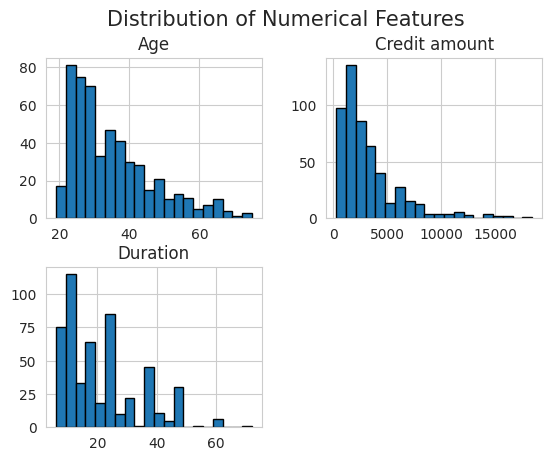

In [20]:
# I'll create histograms to visualize the distribution of key numerical features: 'Age', 'Credit amount', and 'Duration'.
# This helps us understand their spread and common values.
df[["Age", "Credit amount", "Duration",]].hist(bins =20, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features", fontsize = 15)
plt.show()

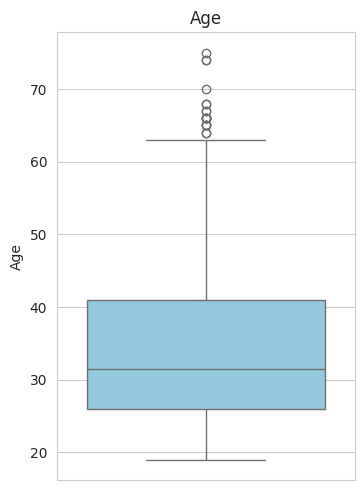

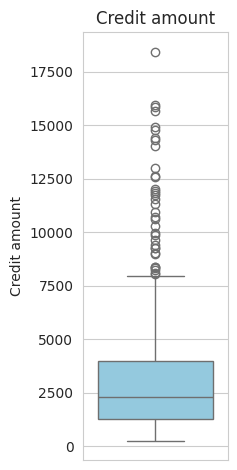

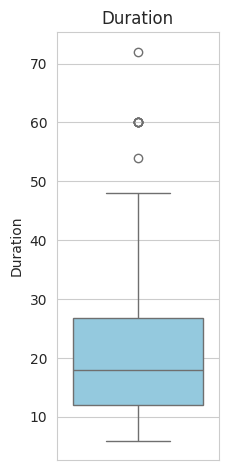

In [21]:
# To further understand the central tendency and identify outliers in our numerical features,
# I will generate box plots for 'Age', 'Credit amount', and 'Duration'.
plt.figure(figsize= (10,5))
for i , col in enumerate (["Age", "Credit amount", "Duration"]):
  plt.subplot(1, 3, i+1)
  sns.boxplot(y = df[col], color ="skyblue")
  plt.title(col)

  plt.tight_layout()
  plt.show()

In [22]:
# I'm filtering the data to find loan applications where the 'Duration' is 60 months or more.
# This helps identify long-term credits in the dataset.
df.query("Duration >= 60")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,29,63,male,2,own,little,little,6836,60,business,bad
176,332,24,female,3,own,moderate,moderate,7408,60,car,bad
199,374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,714,27,male,3,own,little,moderate,14027,60,car,bad
489,938,42,male,2,free,little,moderate,6288,60,education,bad
507,973,36,male,2,rent,little,little,7297,60,business,bad


In [23]:
# Defining a list of categorical columns that will be used for further analysis and visualization.
categorial_cols = ["Sex","Job","Housing","Saving accounts", "Checking account","Purpose"]

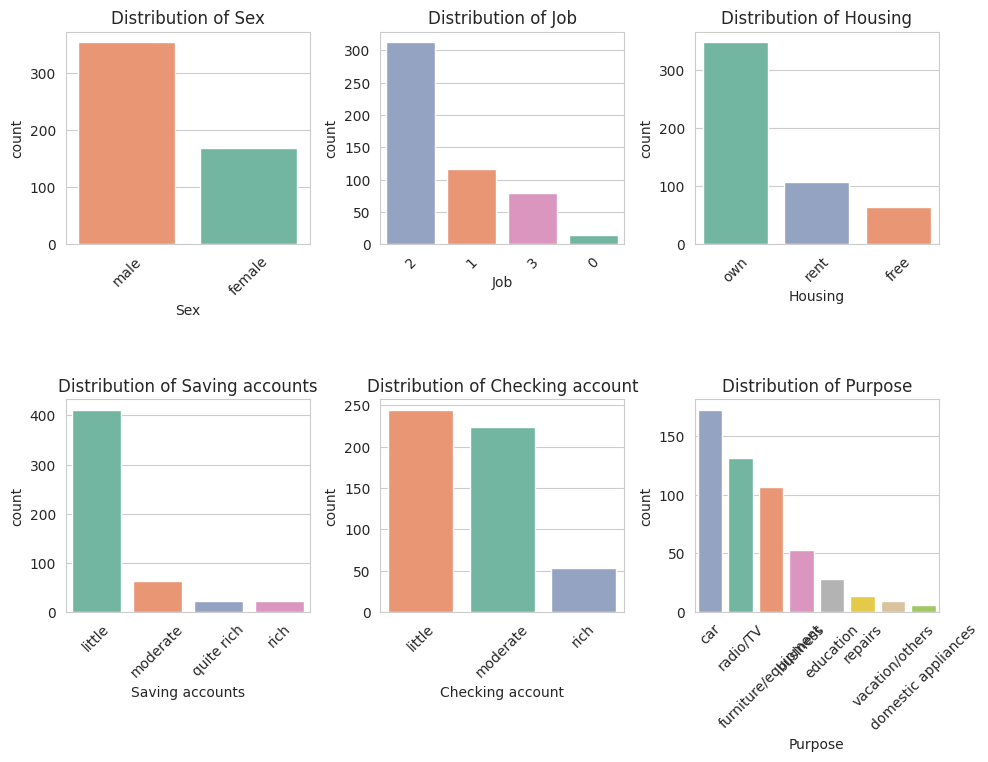

In [24]:
# I will now create count plots for each categorical feature to visualize the distribution of their values.
# This helps in understanding the frequency of each category.
plt.figure(figsize= (10,10))
for i, col in enumerate(categorial_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data= df, x = col, hue = col, palette= "Set2", order = df[col].value_counts().index, legend=False)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# Calculating the correlation matrix for our key numerical features to understand relationships between them.
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [26]:
corr # Display the correlation matrix

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


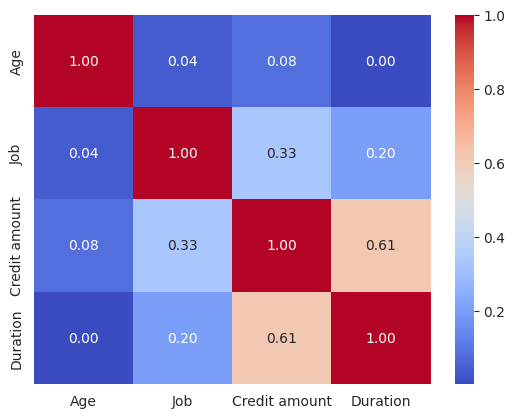

In [27]:
sns.heatmap(corr, annot=True, cmap ="coolwarm", fmt= ".2f")
plt.show() # Visualize the correlation matrix using a heatmap

In [28]:
df.groupby("Job")["Credit amount"].mean() # Calculate the average credit amount grouped by 'Job'

,Credit amount
Job,
0,1767.857143
1,2250.715517
2,3129.130990
3,5648.784810


In [29]:
df.groupby("Sex")["Credit amount"].mean() # Calculate the average credit amount grouped by 'Sex'

,Credit amount
Sex,
female,2937.202381
male,3440.833333


In [30]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns = "Purpose") # Create a pivot table to show average 'Credit amount' by 'Housing' and 'Purpose'

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


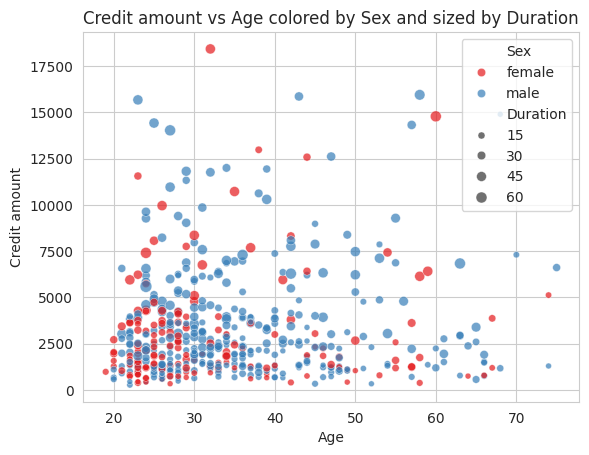

In [31]:
sns.scatterplot(data = df, x="Age", y="Credit amount", hue = "Sex", size ="Duration", alpha=0.7, palette ="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show() # Visualize 'Credit amount' vs 'Age', colored by 'Sex' and sized by 'Duration'

/tmp/ipykernel_103408/4192559993.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x="Saving accounts", y="Credit amount", palette ="Pastel1")


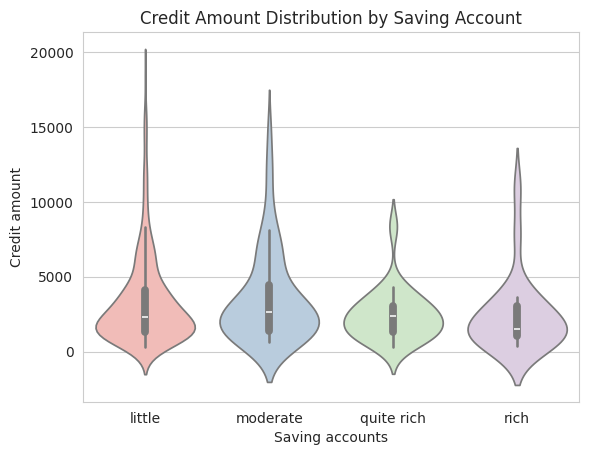

In [32]:
sns.violinplot(data = df, x="Saving accounts", y="Credit amount", palette ="Pastel1")
plt.title("Credit Amount Distribution by Saving Account")
plt.show() # Plot violin plot to show distribution of 'Credit amount' across 'Saving accounts'

In [33]:
df["Risk"].value_counts(normalize= True) * 100 # Show the percentage distribution of the 'Risk' target variable

,proportion
Risk,
good,55.747126
bad,44.252874


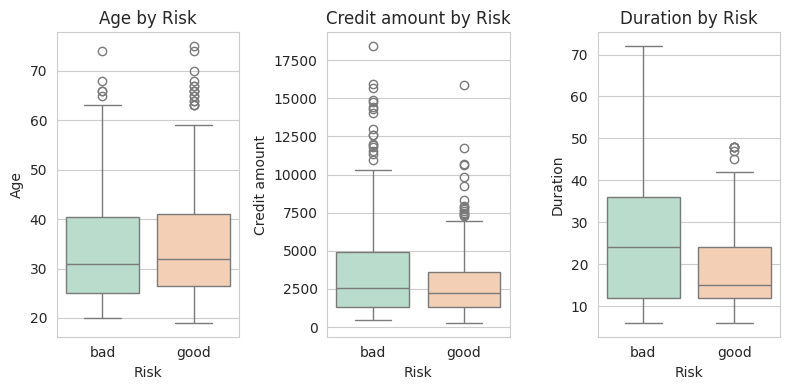

In [34]:
plt.figure(figsize= (8,4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
  plt.subplot(1,3, i+1)
  sns.boxplot(data = df, x = "Risk", y = col, hue="Risk", palette="Pastel2", legend=False)
  plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show() # Plot box plots for numerical features against 'Risk' to see differences between good/bad risks

In [35]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean() # Calculate the average of numerical features for 'good' and 'bad' risks

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [36]:
categorial_cols # Re-display the list of categorical columns

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

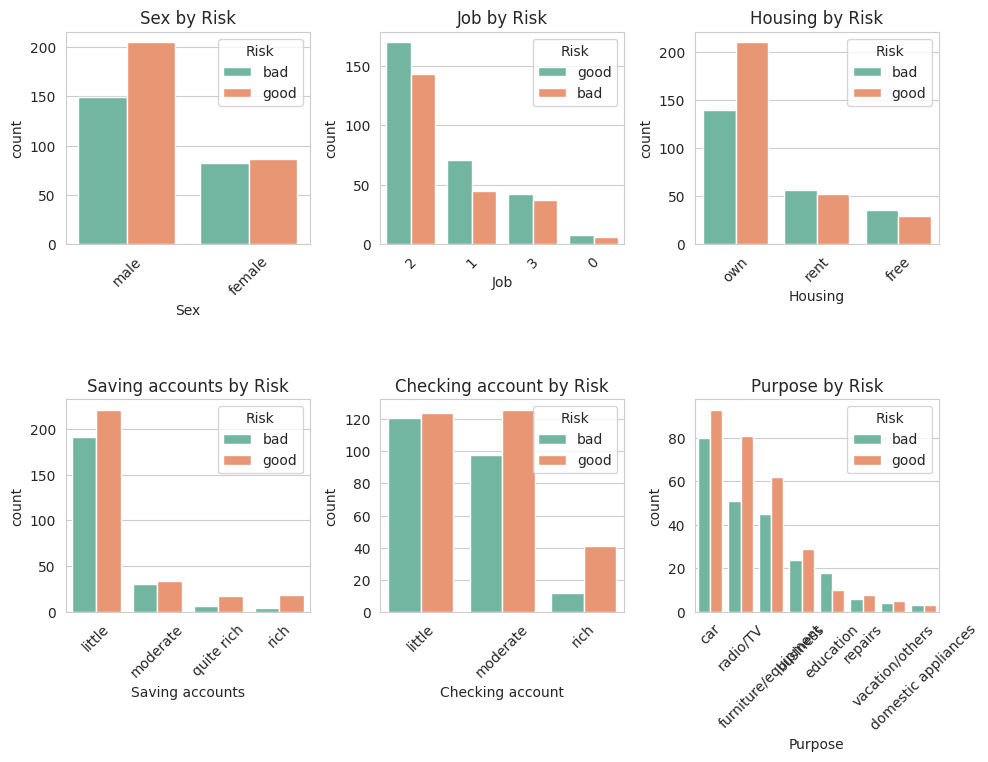

In [37]:
# To understand how categorical features relate to the 'Risk' target variable,
# I will create count plots, distinguishing between 'good' and 'bad' risks for each category.
plt.figure(figsize= (10,10))
for i, col in enumerate(categorial_cols):
  plt.subplot(3,3, i + 1)
  sns.countplot(data = df, x = col, hue = "Risk", palette= "Set2", order = df[col].value_counts().index)
  plt.title(f"{col} by Risk")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
# Displaying the current DataFrame columns before selecting features for the model.
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [39]:
# Defining the list of features (independent variables) that will be used to train our credit risk prediction model.
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account",
       "Credit amount", "Duration"]

In [40]:
# Specifying the target variable, 'Risk', which our model will aim to predict.
target = "Risk"

In [41]:
# Creating a new DataFrame, `df_model`, which includes only the selected features and the target variable.
# This ensures that our modeling data is isolated and contains only relevant columns.
df_model = df[features + [target]].copy()

In [42]:
# Displaying the first few rows of the `df_model` DataFrame to verify its structure after feature selection.
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [43]:
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder for converting categorical to numerical
import joblib # Import joblib to save and load models and encoders

In [44]:
# Identifying categorical columns within our `df_model` that need encoding, excluding the target 'Risk'.
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk", errors='ignore')

In [45]:
# Initializing an empty dictionary to store the LabelEncoder objects for each categorical feature.
# This allows us to reuse these encoders later for new data.
le_dict ={}

In [46]:
# Displaying the list of identified categorical columns that will be encoded.
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [47]:
# Applying Label Encoding to each identified categorical column.
# I'm also storing each fitted encoder in a dictionary and saving it to a file for future use,
# ensuring consistency if new data needs to be processed.
for col in cat_cols:
  le = LabelEncoder()
  df_model[col] = le.fit_transform(df_model[col])
  le_dict[col] = le
  joblib.dump(le, f"{col}_encoder.pkl")

In [48]:
# Initializing a LabelEncoder specifically for our target variable, 'Risk'.
le_target = LabelEncoder()

In [49]:
# Confirming the name of our target variable.
target

'Risk'

In [50]:
# Applying Label Encoding to the target variable 'Risk', converting 'good' and 'bad' into numerical representations (e.g., 0 and 1).
df_model[target] = le_target.fit_transform(df_model[target])

In [51]:
# Checking the distribution of the encoded target variable to see the class balance (now represented as 0s and 1s).
df_model[target].value_counts()

,count
Risk,
1,291
0,231


In [52]:
# Saving the fitted target encoder to a file using `joblib`. This is crucial for inverse transforming predictions later or for processing new data.
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [53]:
# Displaying the head of the DataFrame after all categorical and target variables have been encoded.
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [54]:
from sklearn.model_selection import train_test_split # Import function for splitting data into training and testing sets

In [55]:
# Separating the features (independent variables) from the target variable.
# X will contain all columns except the 'Risk' column.
X = df_model.drop(target, axis = 1)

In [56]:
# Assigning the target variable (dependent variable), 'Risk', to y.
y = df_model[target]

In [57]:
# Displaying the features DataFrame (X).
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [58]:
# Displaying the target Series (y).
y

,Risk
0,0
1,1
2,0
3,1
4,0
...,...
517,1
518,1
519,1
520,0


In [59]:
# Splitting the data into training and testing sets.
# I'm using a 80/20 split (80% for training, 20% for testing) and stratifying by the target variable
# to ensure that both sets have a similar proportion of 'good' and 'bad' risks.
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, stratify = y, random_state = 1)

In [60]:
# Checking the shape of the training features (X_train) to confirm its dimensions.
X_train.shape

(417, 8)

In [61]:
# Checking the shape of the testing features (X_test) to confirm its dimensions.
X_test.shape

(105, 8)

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score # For evaluating model accuracy
from sklearn.model_selection import GridSearchCV # For hyperparameter tuning


In [63]:
# I'm defining a helper function `train_model` to streamline the training and hyperparameter tuning process for different models.
# This function uses GridSearchCV to find the best parameters and evaluates the model's accuracy.
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
  grid =GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy", n_jobs= -1 )
  grid.fit(X_train, y_train)
  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  return best_model, acc, grid.best_params_

In [64]:
# Initializing the Decision Tree Classifier. I'm setting `class_weight='balanced'` to handle potential class imbalance,
# and defining a parameter grid for hyperparameter tuning using GridSearchCV.
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [65]:
# Training and tuning the Decision Tree model using our `train_model` function and the defined parameter grid.
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [66]:
print(f"Decision Tree Accuracy: {acc_dt:.2%}")

Decision Tree Accuracy: 58.10%


In [67]:
print("Best Parameters", params_dt)

Best Parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [68]:
# Initializing the Random Forest Classifier. Similar to Decision Tree, I'm using `class_weight='balanced'`
# and setting `n_jobs=-1` to utilize all available CPU cores for faster training.
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [69]:
# Defining the parameter grid for hyperparameter tuning of the Random Forest model.
rf_param_grid ={
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [70]:
# Training and tuning the Random Forest model using our `train_model` function and its specific parameter grid.
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [71]:
print(f"Random Forest Accuracy: {acc_rf:.2%}")

Random Forest Accuracy: 61.90%


In [72]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [73]:
from sklearn.ensemble import ExtraTreesClassifier

# Initializing the Extra Trees Classifier, similar to Random Forest for ensemble learning.
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [74]:
# Defining the parameter grid for hyperparameter tuning of the Extra Trees model.
et_param_grid ={
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [75]:
# Training and tuning the Extra Trees model using our `train_model` function and its specific parameter grid.
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [76]:
print(f"Extra Trees Accuracy: {acc_et:.2%}")

Extra Trees Accuracy: 64.76%


In [77]:
print("Best params:", params_et)

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [78]:
# Initializing the XGBoost Classifier. I'm setting `scale_pos_weight` to handle class imbalance
# and `eval_metric='logloss'` for appropriate evaluation during boosting.
xgb = XGBClassifier(random_state=1, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), eval_metric='logloss')

In [79]:
# Defining the parameter grid for hyperparameter tuning of the XGBoost model.
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [3, 5, 7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
    }

In [80]:
# Training and tuning the XGBoost model using our `train_model` function and its specific parameter grid.
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [81]:
print(f"XGBoost Accuracy: {acc_xgb:.2%}")

XGBoost Accuracy: 66.67%


In [82]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [83]:
# Generating predictions on the test set using the best performing Extra Trees model.
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [84]:
# Saving the best trained Extra Trees model to a file using `joblib`.
# This allows us to load and use the model later without retraining.
joblib.dump(best_et, "extra_trees_creduit_model.pkl")

['extra_trees_creduit_model.pkl']

#**Model Comparison:**
Different models were tested including Decision Tree, Random Forest, Extra Trees, and XGBoost.

Among all, XGBoost performed the best with an accuracy of 66.67% on the test data.

# **Best Model Evaluation:**
The XGBoost model was further evaluated using classification metrics such as precision, recall, and F1-score.

This helped in understanding how well the model predicts both good and bad credit risks.

In [85]:
# Make predictions with the best performing XGBoost Classifier
y_pred_best_xgb = best_xgb.predict(X_test)

In [86]:
# 1. Evaluate the Accuracy Score
# The accuracy score represents the proportion of correct predictions among the total number of cases.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"\nAccuracy of Best XGBoost Model: {accuracy_best_xgb:.2%}")


Accuracy of Best XGBoost Model: 66.67%



Confusion Matrix (Best XGBoost Model):
[[28 18]
 [17 42]]


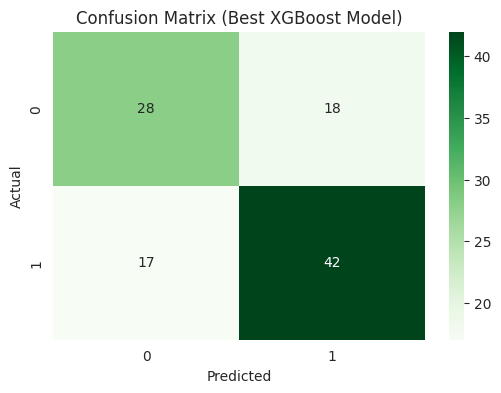

In [87]:
# 2. Analyze the Confusion Matrix
# A confusion matrix visualizes the performance of an algorithm, typically a supervised learning one.
# It shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes.
# Specifically, it breaks down the predictions into True Positives (TP), True Negatives (TN),
# False Positives (FP), and False Negatives (FN).

cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
print("\nConfusion Matrix (Best XGBoost Model):")
print(cm_best_xgb)

# Visualize the Confusion Matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best_xgb, annot=True, fmt='d', cmap='Greens') # Using 'Greens' colormap for clarity
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Best XGBoost Model)')
plt.show()

In [88]:
import joblib # Ensure joblib is imported to load the encoder
from sklearn.metrics import classification_report # Ensure classification_report is imported

# 3. Generate the Classification Report
# The classification report provides a comprehensive overview of the model's performance,
# including precision, recall, and f1-score for each class.
# - Precision: The proportion of positive identifications that were actually correct (TP / (TP + FP)).
# - Recall: The proportion of actual positives that were identified correctly (TP / (TP + FN)).
# - F1-score: The harmonic mean of precision and recall, providing a single metric that balances both.
# - Support: The number of occurrences of each class in the `y_test` dataset.

# To get meaningful labels in the report, we'll load the target encoder to retrieve the original class names.
le_target_loaded = joblib.load('target_encoder.pkl') # Uncommented to load the encoder
target_names = le_target_loaded.classes_

report_best_xgb = classification_report(y_test, y_pred_best_xgb, target_names=target_names)
print("\nClassification Report (Best XGBoost Model):")
print(report_best_xgb)

NameError: name 'le_target_loaded' is not defined